# Morris Sensitivity – Cross-Dataset Comparison

Loads pre-computed Morris μ\* results from all three datasets and produces one
overall figure comparing parameter sensitivity rankings across:

| Dataset | Colour | Description |
|---------|--------|-------------|
| **SNOWPACK** | `C.SNOWPACK` | 18 Alpsolut stations, SNOWPACK-modelled SWE, 2 hydrological years |
| **Win21** | `C.WINKLER` | 15 stations, long-term field SWE measurements, 1959–2022 |
| **Mag25** | `C.MAGNUSSON` | 40 SLF stations, biweekly snow-course SWE, 2016–2022 |

**Prerequisite:** run the three individual Morris notebooks first so the
`morris_results_*.csv` files exist on disk.

In [48]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

ROOT = Path("/Users/jakobwerkgarner/code/mt_dsnow")
sys.path.insert(0, str(ROOT))

from plot_style import apply_style, C, FIG, add_subplot_labels

apply_style()

OUT_DIR = ROOT / "par_sens"

## 1 · Load results from all three datasets

In [49]:
DATASETS = {
    "SNOWPACK": {
        "path":  ROOT / "par_sens/morris_SNOWPACK/morris_results_SP.csv",
        "color": C.SNOWPACK,
        "label": "SNOWPACK",
    },
    "Win21": {
        "path":  ROOT / "par_sens/morris_Win21/morris_results_Win21.csv",
        "color": C.WINKLER,
        "label": "Win21",
    },
    "Mag25": {
        "path":  ROOT / "par_sens/morris_Mag25/morris_results_Mag25.csv",
        "color": C.MAGNUSSON,
        "label": "Mag25",
    },
}

dfs = {}
for key, meta in DATASETS.items():
    if not meta["path"].exists():
        raise FileNotFoundError(
            f"{meta['path']} not found — run {key} Morris notebook first."
        )
    dfs[key] = pd.read_csv(meta["path"])
    print(f"{key:10s}  {len(dfs[key])} parameters  "
          f"μ* range [{dfs[key]['mu_star'].min():.3f}, {dfs[key]['mu_star'].max():.3f}]")

SNOWPACK    7 parameters  μ* range [0.034, 0.518]
Win21       7 parameters  μ* range [0.030, 0.333]
Mag25       7 parameters  μ* range [0.029, 0.380]


In [50]:
dfs['Win21']

,parameter,name,mu_star,mu_star_conf,mu,sigma
0,$\rho_0$,rho_null,0.333457,0.054829,-0.032418,0.390708
1,$\tau$,tau,0.288250,0.046560,0.138834,0.304452
2,$\rho_{max}$,rho_max,0.210340,0.070183,0.201581,0.264286
3,$k$,k,0.190929,0.062874,-0.038200,0.301157
4,$\eta_0$,eta_null,0.075782,0.044717,-0.028992,0.177144
5,$k_{ov}$,k_ov,0.035572,0.027283,-0.018067,0.104204
6,$c_{ov}$,c_ov,0.029511,0.018593,0.006662,0.076043


## 2 · Overall comparison figure

Grouped horizontal bar chart: each parameter group shows μ\* for all three
datasets side-by-side. Parameters are sorted by their mean μ\* rank across
all datasets (most influential at top).

In [51]:
# ── Align on parameter name, merge μ*, σ and CI across all datasets ───────────
def _rename(df, suffix):
    return df[["name", "parameter", "mu_star", "mu_star_conf", "sigma"]].rename(columns={
        "mu_star":      f"mu_star_{suffix}",
        "mu_star_conf": f"conf_{suffix}",
        "sigma":        f"sigma_{suffix}",
    })

merged = (
    _rename(dfs["SNOWPACK"], "SP")
    .merge(_rename(dfs["Win21"],  "Win21").drop(columns="parameter"), on="name")
    .merge(_rename(dfs["Mag25"],  "Mag25").drop(columns="parameter"), on="name")
)
merged["mu_star_mean"] = merged[["mu_star_SP", "mu_star_Win21", "mu_star_Mag25"]].mean(axis=1)
merged = merged.sort_values("mu_star_mean", ascending=True).reset_index(drop=True)

print(merged[["parameter", "mu_star_SP", "mu_star_Win21", "mu_star_Mag25"]].to_string(index=False))

   parameter  mu_star_SP  mu_star_Win21  mu_star_Mag25
    $c_{ov}$    0.034646       0.029511       0.029331
    $k_{ov}$    0.033621       0.035572       0.034233
    $\eta_0$    0.055283       0.075782       0.048569
$\rho_{max}$    0.082846       0.210340       0.198074
         $k$    0.268208       0.190929       0.187031
      $\tau$    0.412351       0.288250       0.223151
    $\rho_0$    0.517738       0.333457       0.379863


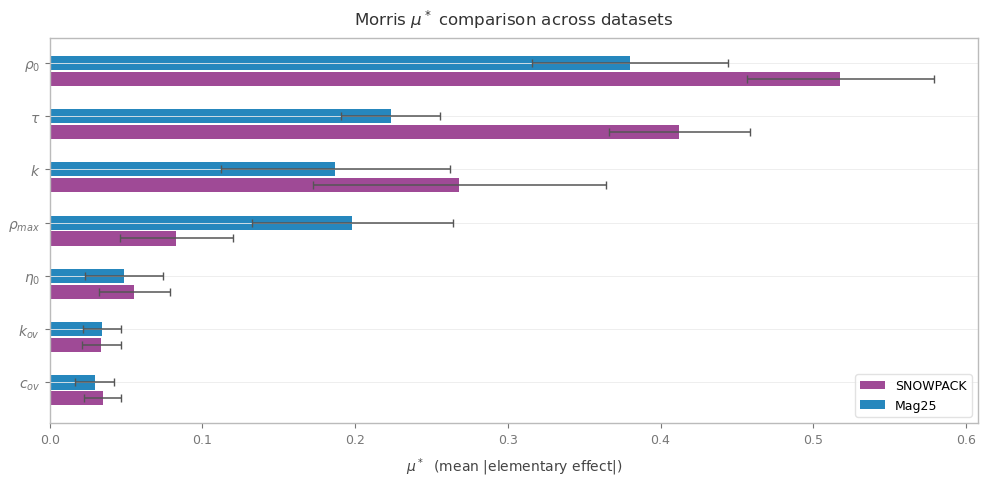

Saved → /Users/jakobwerkgarner/code/mt_dsnow/par_sens/morris_comparison.png


In [52]:
# ── Grouped horizontal bar chart ──────────────────────────────────────────────

n_params  = len(merged)
n_ds      = 3
bar_h     = 0.22          # height of each individual bar
group_gap = 0.08           # extra gap between parameter groups
offsets   = [-bar_h, 0.0, bar_h]   # vertical offsets within a group

ds_order = ["SNOWPACK", "Mag25"]
mu_cols  = ["mu_star_SP", "mu_star_Mag25"]
ci_cols  = ["conf_SP",    "conf_Mag25"]

fig, ax = plt.subplots(figsize=FIG.SINGLE)

y_positions = []   # centre of each parameter group
y_tick_labels = []

for i, row in merged.iterrows():
    y_centre = i * (n_ds * bar_h + group_gap)
    y_positions.append(y_centre)
    y_tick_labels.append(row["parameter"])

    for j, (ds_key, mu_col, ci_col, offset) in enumerate(
        zip(ds_order, mu_cols, ci_cols, offsets)
    ):
        ax.barh(
            y_centre + offset, row[mu_col],
            xerr  = row[ci_col],
            height= bar_h * 0.9,
            color = DATASETS[ds_key]["color"],
            alpha = 0.85,
            error_kw=dict(elinewidth=1.1, ecolor="#555555", capsize=3),
        )

# ── Formatting ────────────────────────────────────────────────────────────────
ax.set_yticks(y_positions)
ax.set_yticklabels(y_tick_labels, fontsize=10)
ax.set_xlabel(r"$\mu^*$  (mean $|$elementary effect$|$)", labelpad=7)
ax.set_title(r"Morris $\mu^*$ comparison across datasets", pad=10)
ax.set_xlim(left=0)

legend_handles = [
    mpatches.Patch(facecolor=DATASETS[k]["color"], alpha=0.85, label=DATASETS[k]["label"])
    for k in ds_order
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=9, framealpha=0.85)

plt.tight_layout()
fig.savefig(OUT_DIR / "morris_comparison.png", **FIG.SAVE)
plt.show()
print(f"Saved → {OUT_DIR / 'morris_comparison.png'}")

## 3 · Morris scatter plots (μ* vs σ) — one panel per dataset

Parameters coloured consistently with the individual notebooks (Okabe-Ito via `C.CYCLE`).
Only the **top 3 parameters** (by μ* within each dataset) are annotated to keep the
plot readable. Each panel has independent axes so cross-dataset scale differences
don't compress one dataset into a corner.

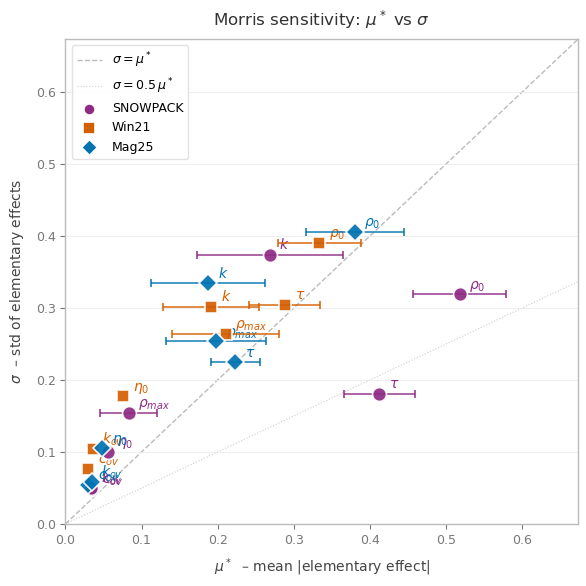

In [53]:
PARAM_NAMES  = ["rho_max", "rho_null", "c_ov", "k_ov", "k", "tau", "eta_null"]
PARAM_LATEX  = [r"$\rho_{max}$", r"$\rho_0$", r"$c_{ov}$",
                r"$k_{ov}$",     r"$k$",       r"$\tau$",   r"$\eta_0$"]
PARAM_COLORS = dict(zip(PARAM_NAMES, C.CYCLE[:len(PARAM_NAMES)]))

ACTIVE = {
    "SNOWPACK": {"marker": "o", "ms": 10},
    "Win21":  {"marker": "s", "ms":  9},
    "Mag25":    {"marker": "D", "ms":  9},
}

lim = max(
    max(dfs[ds]["mu_star"].max(), dfs[ds]["sigma"].max())
    for ds in ACTIVE
) * 1.3

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot([0, lim], [0, lim],       ls="--", lw=1.0, color="#BBBBBB", zorder=0, label=r"$\sigma = \mu^*$")
ax.plot([0, lim], [0, 0.5 * lim], ls=":",  lw=0.8, color="#CCCCCC", zorder=0, label=r"$\sigma = 0.5\,\mu^*$")

# define the 4 most important per dataset


TOP4 = {
    ds_key: set(dfs[ds_key].nlargest(4, "mu_star")["name"])
    for ds_key in ACTIVE
}

for ds_key, cfg in ACTIVE.items():
    df     = dfs[ds_key].set_index("name")
    ds_col = DATASETS[ds_key]["color"]
    for param_name in PARAM_NAMES:
        row   = df.loc[param_name]
        latex = PARAM_LATEX[PARAM_NAMES.index(param_name)]
        ax.errorbar(
            row["mu_star"], row["sigma"],
            xerr=row["mu_star_conf"] if param_name in TOP4[ds_key] else None,
            fmt=cfg["marker"], ms=cfg["ms"],
            color=ds_col, ecolor=ds_col, elinewidth=1.1, capsize=3,
            zorder=4, alpha=0.92,
            markeredgecolor="white", markeredgewidth=1.2,
        )
        ax.annotate(
            latex,
            xy=(row["mu_star"], row["sigma"]),
            xytext=(7, 4), textcoords="offset points",
            fontsize=10, color=ds_col, fontweight="bold",
        )
    ax.scatter([], [], marker=cfg["marker"], s=65,
               facecolor=ds_col, edgecolors="white", linewidths=1.2,
               label=DATASETS[ds_key]["label"])

ax.set_xlim(0, lim);  ax.set_ylim(0, lim)
ax.set_xlabel(r"$\mu^*$  – mean $|$elementary effect$|$", labelpad=7)
ax.set_ylabel(r"$\sigma$  – std of elementary effects",   labelpad=7)
ax.set_title(r"Morris sensitivity: $\mu^*$ vs $\sigma$", pad=10)
ax.legend(loc="upper left", fontsize=9, framealpha=0.85)

plt.tight_layout()
fig.savefig(OUT_DIR / "morris_scatter_comparison.png", **FIG.SAVE)
plt.show()